# Lumbar spine classification of MRI slices
## Dataset


In [51]:
import numpy as np
from PIL import Image
import os 
from collections import Counter
import matplotlib.pyplot as plt
import random
import numpy as np
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

import copy
import time
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import f1_score, accuracy_score

In [34]:
os.chdir("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
print(os.getcwd())

/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data


In [35]:
def count_images(data_dir):
    class_counts = {}
    
    for split in ["train", "test"]:
        split_path = os.path.join(data_dir, split)
        class_counts[split] = {}
        
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                class_counts[split][cls] = len(os.listdir(cls_path))
    
    return class_counts

data_dir = "./data-classification"
counts = count_images(data_dir)

counts

{'train': {'No Stenosis': 3152, 'Thecal Sac': 4733, 'Herniated Disc': 3064},
 'test': {'No Stenosis': 1507, 'Thecal Sac': 13, 'Herniated Disc': 1218}}

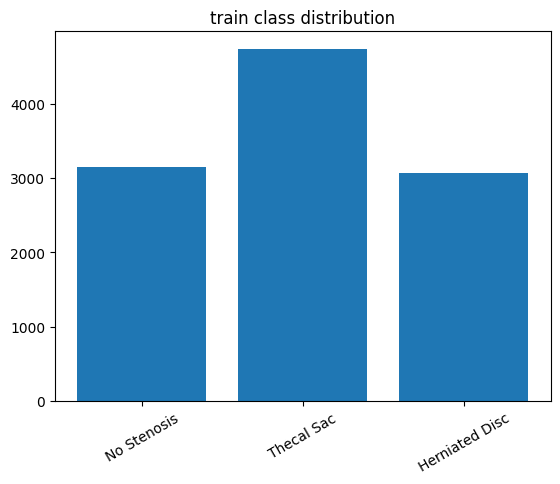

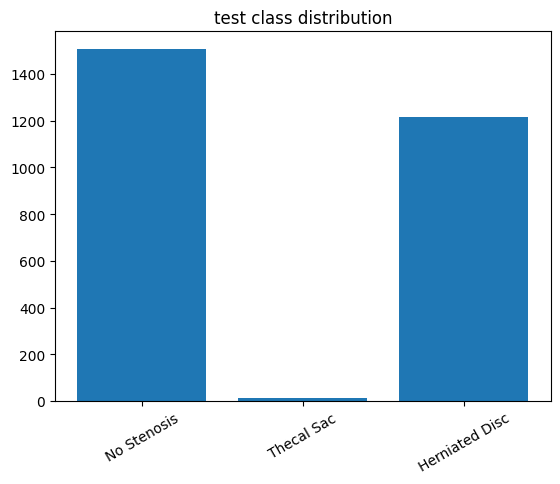

In [36]:
def plot_distribution(counts, split):
    classes = list(counts[split].keys())
    values = list(counts[split].values())
    
    plt.figure()
    plt.bar(classes, values)
    plt.title(f"{split} class distribution")
    plt.xticks(rotation=30)
    plt.show()

plot_distribution(counts, "train")
plot_distribution(counts, "test")

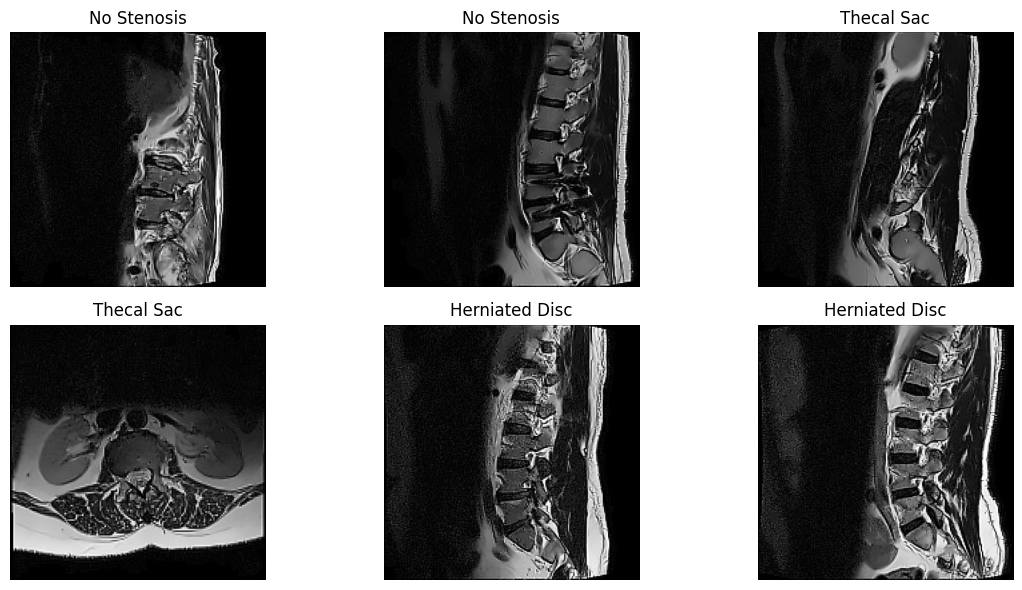

In [37]:
def show_samples(data_dir, split="train", num_samples=6):
    plt.figure(figsize=(12, 6))
    
    i = 1
    for cls in os.listdir(os.path.join(data_dir, split)):
        cls_path = os.path.join(data_dir, split, cls)
        images = os.listdir(cls_path)
        
        for _ in range(num_samples // 3):
            img_name = random.choice(images)
            img_path = os.path.join(cls_path, img_name)
            
            img = Image.open(img_path)
            
            plt.subplot(2, 3, i)
            plt.imshow(img, cmap="gray")
            plt.title(cls)
            plt.axis("off")
            i += 1
    
    plt.tight_layout()
    plt.show()

show_samples(data_dir)

In [38]:
def inspect_images(data_dir, split="train", n=50):
    sizes = []
    dtypes = []
    
    for cls in os.listdir(os.path.join(data_dir, split)):
        cls_path = os.path.join(data_dir, split, cls)
        images = os.listdir(cls_path)[:n]
        
        for img_name in images:
            img_path = os.path.join(cls_path, img_name)
            img = np.array(Image.open(img_path))
            
            sizes.append(img.shape)
            dtypes.append(img.dtype)
    
    print("Unique shapes:", set(sizes))
    print("Unique dtypes:", set(dtypes))

inspect_images(data_dir)

Unique shapes: {(400, 400, 3)}
Unique dtypes: {dtype('uint8')}


In [40]:
# pick one sample image
sample_class = os.listdir(os.path.join(data_dir, "train"))[0]
sample_image = os.listdir(os.path.join(data_dir, "train", sample_class))[0]

img_path = os.path.join(data_dir, "train", sample_class, sample_image)

img = Image.open(img_path)
print(img.mode)
print(img.size)

RGB
(400, 400)


In [42]:
img = np.array(Image.open(img_path))

print("Channels equal:",
      np.all(img[:,:,0] == img[:,:,1]) and np.all(img[:,:,1] == img[:,:,2]))

Channels equal: True


In [43]:
def compute_mean_std(data_dir, n=500):

    pixels = []
    
    for _ in range(n):
        path = img_path
        img = np.array(Image.open(path)) / 255.0
        pixels.append(img)
    
    pixels = np.concatenate([p.flatten() for p in pixels])
    
    print("Mean:", pixels.mean())
    print("Std:", pixels.std())

compute_mean_std(data_dir)

Mean: 0.1669754166666658
Std: 0.23722958871252095


In [44]:
mean = [0.167, 0.167, 0.167]
std  = [0.237, 0.237, 0.237]

In [45]:

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomRotation(5),
    #transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.167, 0.167, 0.167],
        std=[0.237, 0.237, 0.237]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.167, 0.167, 0.167],
        std=[0.237, 0.237, 0.237]
    )
])

In [47]:
dataset = ImageFolder(root="./data-classification/train",
                      transform=train_transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform
test_dataset = ImageFolder(
    root="./data-classification/test",
    transform=val_transform
)

In [48]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [49]:
np.random.seed(42)

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [53]:
base_dataset = ImageFolder(root="./data-classification/train")
class_names = base_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
Number of classes: 3


In [54]:
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/jupyter-lukj08@vse.cz/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 102MB/s] 


Linear(in_features=512, out_features=3, bias=True)


In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

In [55]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return epoch_loss, epoch_acc, epoch_f1

In [57]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return epoch_loss, epoch_acc, epoch_f1

In [58]:
def fit_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }
    
    start_time = time.time()
    
    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )
        
        scheduler.step(val_f1)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
        )
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, "best_resnet34.pth")
            print(f"  -> Best model saved with Val F1: {best_val_f1:.4f}")
    
    elapsed = time.time() - start_time
    print(f"\nTraining complete in {elapsed/60:.2f} minutes")
    print(f"Best Val F1: {best_val_f1:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, history

In [59]:
model, history = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.8317, Train Acc: 0.6182, Train F1: 0.6035 | Val Loss: 0.5919, Val Acc: 0.7545, Val F1: 0.7434
  -> Best model saved with Val F1: 0.7434
Epoch [2/10] | Train Loss: 0.3222, Train Acc: 0.8830, Train F1: 0.8796 | Val Loss: 0.5900, Val Acc: 0.7914, Val F1: 0.7690
  -> Best model saved with Val F1: 0.7690
Epoch [3/10] | Train Loss: 0.1344, Train Acc: 0.9528, Train F1: 0.9516 | Val Loss: 0.4147, Val Acc: 0.8622, Val F1: 0.8551
  -> Best model saved with Val F1: 0.8551
Epoch [4/10] | Train Loss: 0.0997, Train Acc: 0.9655, Train F1: 0.9647 | Val Loss: 0.2510, Val Acc: 0.9078, Val F1: 0.9033
  -> Best model saved with Val F1: 0.9033
Epoch [5/10] | Train Loss: 0.0537, Train Acc: 0.9825, Train F1: 0.9820 | Val Loss: 0.3051, Val Acc: 0.9028, Val F1: 0.8972
Epoch [6/10] | Train Loss: 0.0837, Train Acc: 0.9700, Train F1: 0.9691 | Val Loss: 0.6526, Val Acc: 0.8298, Val F1: 0.8187
Epoch [7/10] | Train Loss: 0.0520, Train Acc: 0.9830, Train F1: 0.9827 | Val Loss: 0.2220, Val

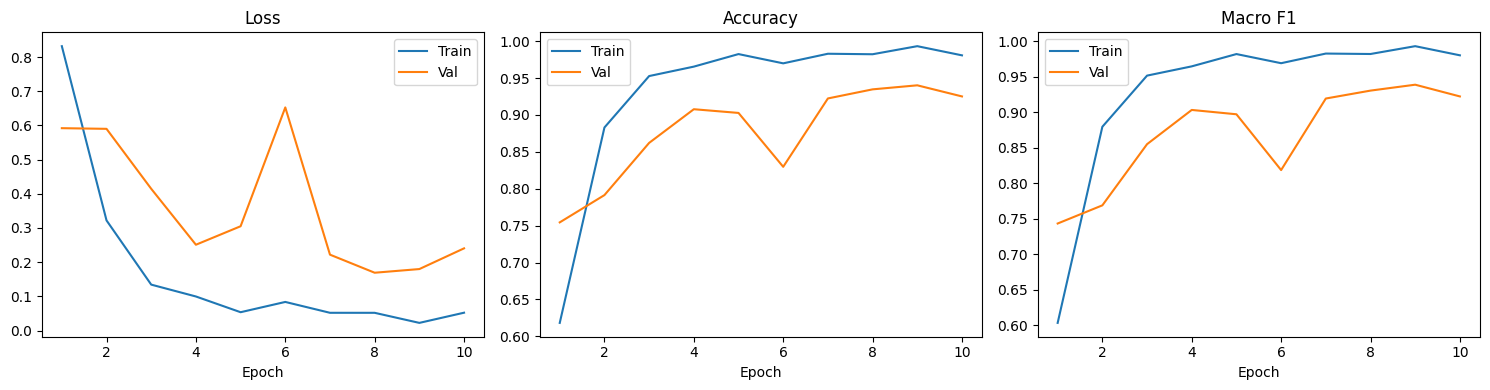

In [60]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_f1"], label="Train")
    plt.plot(epochs, history["val_f1"], label="Val")
    plt.title("Macro F1")
    plt.xlabel("Epoch")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [61]:
test_loss, test_acc, test_f1 = validate_one_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")

Test Loss: 3.5345
Test Accuracy: 0.3762
Test Macro F1: 0.3060
